# Automated Sales/Ops MIS Reporting Pipeline

In this project, we will automate the process of:

- Data Cleaning
- Data Validation
- KPI Reporting
- Sales Analysis
- Profit Analysis
- Monthly MIS Reporting
- Automated Report Generation

Tools Used:
- Python
- Pandas
- NumPy
- OpenPyXL

In [1]:
import numpy as np
import pandas as pd

## Load the Dataset

The Global Superstore dataset contains:

- Orders
- Customers
- Products
- Regions
- Markets
- Sales
- Profit
- Discounts
- Shipping Details

We will first load the Excel file and inspect its structure.

In [3]:
df = pd.read_csv(
    "C:/Users/surek/OneDrive/Desktop/Global_Superstore2.csv",
    encoding="ISO-8859-1"
)

In [4]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,29002,IN-2014-62366,19-06-2014,19-06-2014,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.01,Medium
51286,35398,US-2014-102288,20-06-2014,24-06-2014,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.01,Medium
51287,40470,US-2013-155768,02-12-2013,02-12-2013,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.01,High
51288,9596,MX-2012-140767,18-02-2012,22-02-2012,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.00,Medium


## Dataset Dimensions

The `shape` attribute tells us:

- Total number of rows (transactions)
- Total number of columns (features)

This helps us understand the size of the dataset before performing analysis.

In [5]:
df.shape

(51290, 24)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [9]:
for columns  in  df.columns:
    print(columns)

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
City
State
Country
Postal Code
Market
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit
Shipping Cost
Order Priority


## Missing Value Analysis

Missing values can lead to inaccurate KPIs and business reports.

We will identify the number of missing valuesin each column.

In [11]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Row ID             0.00000
Order ID           0.00000
Order Date         0.00000
Ship Date          0.00000
Ship Mode          0.00000
Customer ID        0.00000
Customer Name      0.00000
Segment            0.00000
City               0.00000
State              0.00000
Country            0.00000
Postal Code       80.51472
Market             0.00000
Region             0.00000
Product ID         0.00000
Category           0.00000
Sub-Category       0.00000
Product Name       0.00000
Sales              0.00000
Quantity           0.00000
Discount           0.00000
Profit             0.00000
Shipping Cost      0.00000
Order Priority     0.00000
dtype: float64

## Duplicate Record Analysis

Duplicate transactions can affect revenue calculations and KPI reporting.

We will identify duplicate records in the dataset.

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(51290, 24)

## Statistical Summary

The `describe()` function provides important statistical information such as:

- Mean
- Minimum
- Maximum
- Standard Deviation
- Quartiles

This helps identify unusual values and understand business performance.

In [20]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [22]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
count,51290.00000,51290,51290,51290,51290,51290,51290,51290,51290,51290,...,51290,51290,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290
unique,NaN,25035,1430,1464,4,1590,795,3,3636,1094,...,10292,3,17,3788,NaN,NaN,NaN,NaN,NaN,4
top,NaN,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,...,OFF-AR-10003651,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,14,135,130,30775,97,108,26518,915,2001,...,35,31273,6152,227,NaN,NaN,NaN,NaN,NaN,29433
mean,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,246.490581,3.476545,0.142908,28.610982,26.375915,NaN
std,14806.29199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,487.565361,2.278766,0.212280,174.340972,57.296804,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.000000,NaN
25%,12823.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,30.758625,2.000000,0.000000,0.000000,2.610000,NaN
50%,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,85.053000,3.000000,0.000000,9.240000,7.790000,NaN
75%,38467.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,251.053200,5.000000,0.200000,36.810000,24.450000,NaN


## Data Type Validation

Validating data types is an important step before KPI calculations.

We will ensure that:

- Dates are in datetime format.
- Sales is numeric.
- Profit is numeric.
- Quantity is numeric.

In [24]:
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code       float64
Market             object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority     object
dtype: object

In [29]:
df["Order Date"].dtype

dtype('O')

In [33]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [34]:
df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object
Postal Code              float64
Market                    object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
dtype: object

In [40]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Day"] = df["Order Date"].dt.day

In [41]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Year,Month,Day
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,2012,7,31
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2013,2,5
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,2013,10,17
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,2013,1,28
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,2013,11,5


## Total Sales

Total Sales represents the overall revenue generated from all orders.

Business Question:
- How much revenue has the company generated?

In [45]:
total_sales = df["Sales"].sum()

print("Total Sales :", round(total_sales, 2))

Total Sales : 12642501.91


## Total Profit

Total Profit represents the net earnings after discounts and costs.

Business Question:
- Is the business profitable?

In [47]:
total_profit = df["Profit"].sum()

print("Total Profit :", round(total_profit,2))

Total Profit : 1467457.29


## Total Orders

This KPI helps us understand the total number of orders received.

Business Question:
- How many orders were placed?

In [50]:
total_orders = df["Order ID"].nunique()

print("Total Orders :", round(total_orders,2))

Total Orders : 25035


## Total Quantity Sold

Business Question:
- How many units were sold?

In [57]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold :", total_quantity)

Total Quantity Sold : 178312


## Average Order Value (AOV)

Average Order Value helps businesses understand customer spending behavior.

Formula:

Average Order Value = Total Sales / Total Orders

In [63]:
average_order_value = total_sales / total_orders

print("Average Order Value :", round(average_order_value,2))

Average Order Value : 504.99


In [65]:
profit_margin = (total_sales / total_profit)*100

print("Profit Margin :", round(profit_margin,2))

Profit Margin : 861.52


## KPI Summary Report

MIS teams often prepare a KPI summary for business stakeholders.

This table provides a quick overview of business performance.

In [67]:
kpi_summary = pd.DataFrame({

    "KPI": [

        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Quantity Sold",
        "Average Order Value",
        "Profit Margin (%)"

    ],

    "Value": [

        round(total_sales,2),
        round(total_profit,2),
        total_orders,
        total_quantity,
        round(average_order_value,2),
        round(profit_margin,2)

    ]

})

kpi_summary

,KPI,Value
0,Total Sales,12642501.91
1,Total Profit,1467457.29
2,Total Orders,25035.00
3,Total Quantity Sold,178312.00
4,Average Order Value,504.99
5,Profit Margin (%),861.52


## Export KPI Report

Exporting reports is a common MIS responsibility.

In [68]:
kpi_summary.to_csv(
    
    "KPI_Summary_Report.csv",

    index=False

)

## Top 10 Products by Sales

Business Question:
- Which products are generating the highest revenue?

In [70]:
top_products = (

    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)

)

top_products

Product Name
Apple Smart Phone, Full Size                                86935.7786
Cisco Smart Phone, Full Size                                76441.5306
Motorola Smart Phone, Full Size                             73156.3030
Nokia Smart Phone, Full Size                                71904.5555
Canon imageCLASS 2200 Advanced Copier                       61599.8240
Hon Executive Leather Armchair, Adjustable                  58193.4841
Office Star Executive Leather Armchair, Adjustable          50661.6840
Harbour Creations Executive Leather Armchair, Adjustable    50121.5160
Samsung Smart Phone, Cordless                               48653.4600
Nokia Smart Phone, with Caller ID                           47877.7857
Name: Sales, dtype: float64

In [71]:
top_profit_products = (

    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)

)

top_profit_products

Product Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64

## Sales by Category

Business Question:
- Which category performs best?

In [72]:
category_sales = (

    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)

)

category_sales

Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64

In [75]:
sub_category_Sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
sub_category_Sales

Sub-Category
Phones         1.706824e+06
Copiers        1.509436e+06
Chairs         1.501682e+06
Bookcases      1.466572e+06
Storage        1.127086e+06
Appliances     1.011064e+06
Machines       7.790601e+05
Tables         7.570419e+05
Accessories    7.492370e+05
Binders        4.619115e+05
Furnishings    3.855783e+05
Art            3.720920e+05
Paper          2.442917e+05
Supplies       2.430742e+05
Envelopes      1.709043e+05
Fasteners      8.324232e+04
Labels         7.340403e+04
Name: Sales, dtype: float64

## Monthly Sales Report

Business Question:
- Which month generated the highest sales?

In [77]:
monthly_sales = (

    df.groupby("Month")["Sales"]
    .sum()
    .sort_values()

)

monthly_sales

Month
2     5.437394e+05
1     6.751337e+05
4     6.985612e+05
7     7.493818e+05
3     7.705009e+05
5     9.040123e+05
10    1.168184e+06
6     1.269717e+06
8     1.293833e+06
9     1.437380e+06
11    1.551277e+06
12    1.580781e+06
Name: Sales, dtype: float64

In [79]:
monthly_Profit = (
    df.groupby("Month")["Profit"]
    .sum()
    .sort_values()
)

monthly_Profit

Month
2      70932.19922
4      73513.63124
1      73535.38454
7      78070.09172
3      94087.52096
5     104509.78428
6     147079.41684
8     151854.10972
10    157269.35838
9     170438.18316
12    170718.12710
11    175449.48412
Name: Profit, dtype: float64

## Region-wise Sales Report

Business Question:
- Which region is generating the highest sales?

This report helps management identify top-performing regions and make strategic decisions.

In [80]:

region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
Central           2.822303e+06
South             1.600907e+06
North             1.248166e+06
Oceania           1.100185e+06
Southeast Asia    8.844232e+05
North Asia        8.483098e+05
EMEA              8.061613e+05
Africa            7.837732e+05
Central Asia      7.528266e+05
West              7.254578e+05
East              6.787812e+05
Caribbean         3.242809e+05
Canada            6.692817e+04
Name: Sales, dtype: float64

In [81]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit

Region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: Profit, dtype: float64

## Market-wise Sales Report

Business Question:
- Which market contributes the most revenue?

Examples:
- APAC
- US
- LATAM
- Europe

In [82]:
market_sales = (
    df.groupby("Market")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

market_sales

Market
APAC      3.585744e+06
EU        2.938089e+06
US        2.297201e+06
LATAM     2.164605e+06
EMEA      8.061613e+05
Africa    7.837732e+05
Canada    6.692817e+04
Name: Sales, dtype: float64

In [83]:
country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

Country
United States     2.297201e+06
Australia         9.252359e+05
France            8.589311e+05
China             7.005620e+05
Germany           6.288400e+05
Mexico            6.225906e+05
India             5.896501e+05
United Kingdom    5.285763e+05
Indonesia         4.048875e+05
Brazil            3.611064e+05
Name: Sales, dtype: float64

In [85]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       6.507949e+06
Corporate      3.824698e+06
Home Office    2.309855e+06
Name: Sales, dtype: float64

In [86]:
segment_profit = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

segment_profit

Segment
Consumer       749239.78206
Corporate      441208.32866
Home Office    277009.18056
Name: Profit, dtype: float64

## Top Customers Analysis

Business Question:
- Who are our highest-value customers?

In [88]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Tom Ashbrook          40488.07080
Tamara Chand          37457.33300
Greg Tran             35550.95428
Christopher Conant    35187.07640
Sean Miller           35170.93296
Bart Watters          32310.44650
Natalie Fritzler      31781.25850
Fred Hopkins          30400.67452
Jane Waco             30288.45030
Hunter Lopez          30243.56658
Name: Sales, dtype: float64

In [89]:
shipping_sales = (
    df.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

shipping_sales

Ship Mode
Standard Class    7.578652e+06
Second Class      2.565672e+06
First Class       1.830976e+06
Same Day          6.672020e+05
Name: Sales, dtype: float64

In [90]:
priority_sales = (
    df.groupby("Order Priority")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

priority_sales

Order Priority
Medium      7.280892e+06
High        3.807548e+06
Critical    9.862355e+05
Low         5.678259e+05
Name: Sales, dtype: float64

In [91]:
total_discount = df["Discount"].sum()

print(total_discount)

7329.728


In [92]:
average_discount = df["Discount"].mean()

print(round(average_discount,2))

0.14


In [93]:
loss_transactions = df[df["Profit"] < 0]

loss_transactions.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Year,Month,Day
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2013,2,5
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,2013,1,28
9,40936,CA-2012-116638,2012-01-28,2012-01-31,Second Class,JH-15985,Joseph Holt,Consumer,Concord,North Carolina,...,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124,865.74,Critical,2012,1,28
30,220,US-2011-128776,2011-12-28,2011-12-30,Second Class,RR-19525,Rick Reed,Corporate,Santo Domingo,Santo Domingo,...,"Samsung Smart Phone, VoIP",1696.640,5,0.2,-148.4600,704.06,Critical,2011,12,28
32,32735,CA-2012-139731,2012-10-15,2012-10-15,Same Day,JE-15745,Joel Eaton,Consumer,Amarillo,Texas,...,HON 5400 Series Task Chairs for Big and Tall,2453.430,5,0.3,-350.4900,690.42,High,2012,10,15


In [97]:
len(loss_transactions)

12544

In [98]:
loss_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

loss_products

Product Name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Motorola Smart Phone, Cordless                             -4447.0380
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Rogers Lockers, Blue                                       -2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, with Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
Name: Profit, dtype: float64

In [99]:
monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
)

monthly_sales

Month
1     6.751337e+05
2     5.437394e+05
3     7.705009e+05
4     6.985612e+05
5     9.040123e+05
6     1.269717e+06
7     7.493818e+05
8     1.293833e+06
9     1.437380e+06
10    1.168184e+06
11    1.551277e+06
12    1.580781e+06
Name: Sales, dtype: float64

In [100]:
monthly_profit = (
    df.groupby("Month")["Profit"]
    .sum()
)

monthly_profit

Month
1      73535.38454
2      70932.19922
3      94087.52096
4      73513.63124
5     104509.78428
6     147079.41684
7      78070.09172
8     151854.10972
9     170438.18316
10    157269.35838
11    175449.48412
12    170718.12710
Name: Profit, dtype: float64

In [101]:
df["Quarter"] = df["Order Date"].dt.quarter

In [102]:
quarter_sales = (
    df.groupby("Quarter")["Sales"]
    .sum()
)

quarter_sales

Quarter
1    1.989374e+06
2    2.872290e+06
3    3.480595e+06
4    4.300243e+06
Name: Sales, dtype: float64

In [103]:
year_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)

year_sales

Year
2011    2.259451e+06
2012    2.677439e+06
2013    3.405746e+06
2014    4.299866e+06
Name: Sales, dtype: float64

In [105]:
year_profit = (
    df.groupby("Year")["Profit"]
    .sum()
)

year_profit

Year
2011    248940.81154
2012    307415.27910
2013    406935.23018
2014    504165.97046
Name: Profit, dtype: float64

In [106]:
import os

os.makedirs("reports", exist_ok=True)

## Export KPI Summary Report

In [107]:
kpi_summary.to_csv(
    "reports/KPI_Summary.csv",
    index=False
)

In [108]:
region_sales.to_csv(
    "reports/Region_Sales.csv"
)

In [109]:
market_sales.to_csv(
    "reports/Market_Sales.csv"
)

In [110]:
category_sales.to_csv(
    "reports/Category_Sales.csv"
)

In [111]:
monthly_profit.to_csv(
    "reports/Monthly_Profit.csv"
)

In [112]:
top_customers.to_csv(
    "reports/Top_Customers.csv"
)

In [113]:
top_products.to_csv(
    "reports/Top_Products.csv"
)

In [114]:
loss_products.to_csv(
    "reports/Loss_Making_Products.csv"
)

## Create Automated MIS Workbook

We will create a single Excel workbook containing:

- KPI Summary
- Region Report
- Market Report
- Category Report
- Monthly Sales Report
- Monthly Profit Report
- Top Products Report
- Top Customers Report
- Loss Report

In [116]:
with pd.ExcelWriter(
    "reports/MIS_Report.xlsx",
    engine="openpyxl"
) as writer:

    kpi_summary.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    region_sales.to_excel(
        writer,
        sheet_name="Region Sales"
    )

    market_sales.to_excel(
        writer,
        sheet_name="Market Sales"
    )

    category_sales.to_excel(
        writer,
        sheet_name="Category Sales"
    )

    monthly_sales.to_excel(
        writer,
        sheet_name="Monthly Sales"
    )

    monthly_profit.to_excel(
        writer,
        sheet_name="Monthly Profit"
    )

    top_products.to_excel(
        writer,
        sheet_name="Top Products"
    )

    top_customers.to_excel(
        writer,
        sheet_name="Top Customers"
    )

    loss_products.to_excel(
        writer,
        sheet_name="Loss Products"
    )

print("MIS Report Generated Successfully!")

MIS Report Generated Successfully!


In [117]:
import os

os.listdir("reports")

['Category_Sales.csv',
 'KPI_Summary.csv',
 'Loss_Making_Products.csv',
 'Market_Sales.csv',
 'MIS_Report.xlsx',
 'Monthly_Profit.csv',
 'Region_Sales.csv',
 'Top_Customers.csv',
 'Top_Products.csv']

In [118]:
def calculate_total_sales(data):

    return data["Sales"].sum()


def calculate_total_profit(data):

    return data["Profit"].sum()


def calculate_total_orders(data):

    return data["Order ID"].nunique()

In [119]:
sales = calculate_total_sales(df)
profit = calculate_total_profit(df)
orders = calculate_total_orders(df)

print(sales)
print(profit)
print(orders)

12642501.909880001
1467457.29128
25035


In [120]:
def generate_kpi_report(data):

    total_sales = data["Sales"].sum()

    total_profit = data["Profit"].sum()

    total_orders = data["Order ID"].nunique()

    return pd.DataFrame({

        "KPI":[
            "Total Sales",
            "Total Profit",
            "Total Orders"
        ],

        "Value":[
            total_sales,
            total_profit,
            total_orders
        ]

    })

In [121]:
kpi_report = generate_kpi_report(df)

kpi_report

,KPI,Value
0,Total Sales,1.264250e+07
1,Total Profit,1.467457e+06
2,Total Orders,2.503500e+04


## Sales Trend Analysis

Visualizing sales trends helps stakeholders identify seasonal patterns and business performance over time.

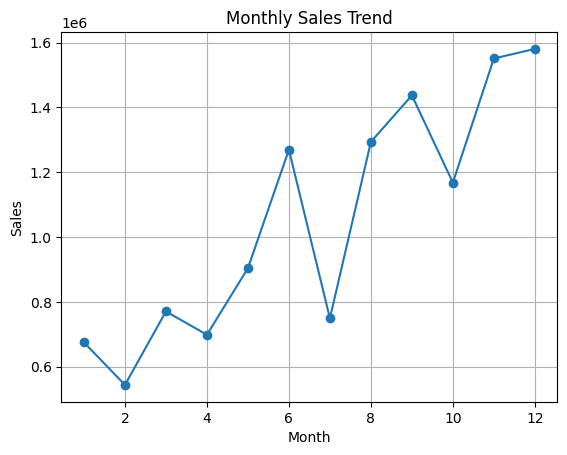

In [122]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

## Monthly Profit Trend

This report helps management understand profitability trends across different months.

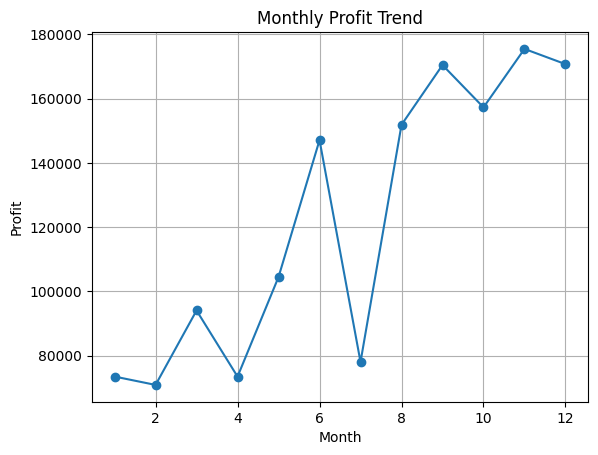

In [123]:
monthly_profit.plot(kind="line", marker="o")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.grid(True)
plt.show()

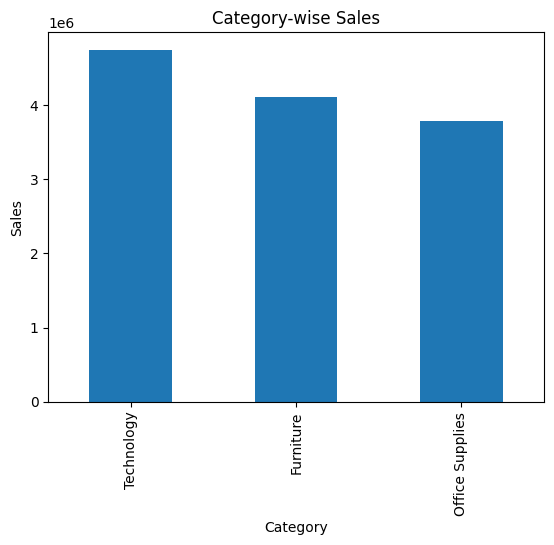

In [124]:
category_sales.plot(kind="bar")

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

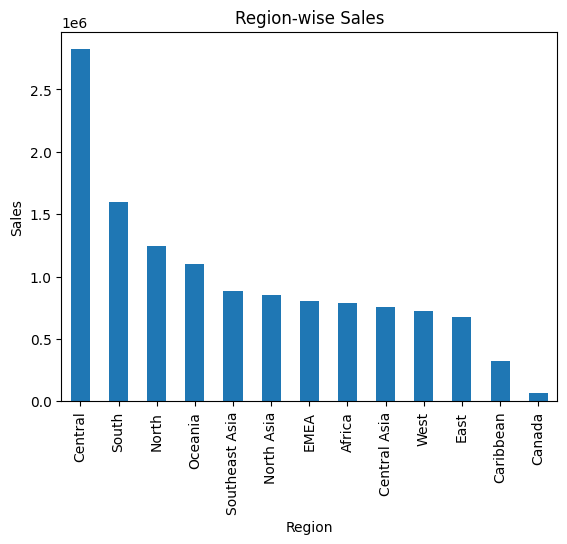

In [125]:
region_sales.plot(kind="bar")

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

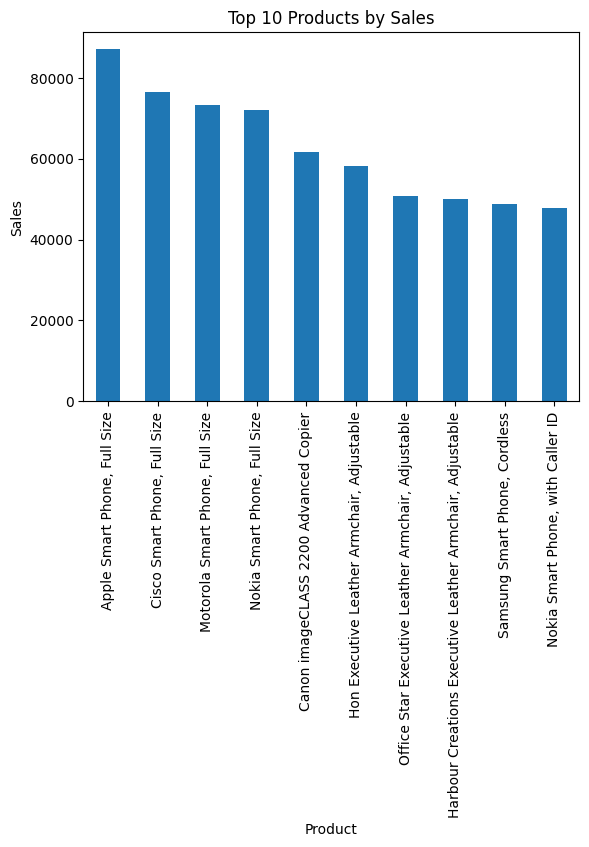

In [126]:
top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()

## Executive Summary Report

This summary report is useful for managers and stakeholders.

In [127]:
executive_summary = pd.DataFrame({

    "Metric": [

        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Average Order Value",
        "Profit Margin (%)"

    ],

    "Value": [

        round(total_sales,2),
        round(total_profit,2),
        total_orders,
        round(average_order_value,2),
        round(profit_margin,2)

    ]

})

executive_summary

,Metric,Value
0,Total Sales,12642501.91
1,Total Profit,1467457.29
2,Total Orders,25035.00
3,Average Order Value,504.99
4,Profit Margin (%),861.52


In [128]:
executive_summary.to_csv(

    "reports/Executive_Summary.csv",

    index=False

)

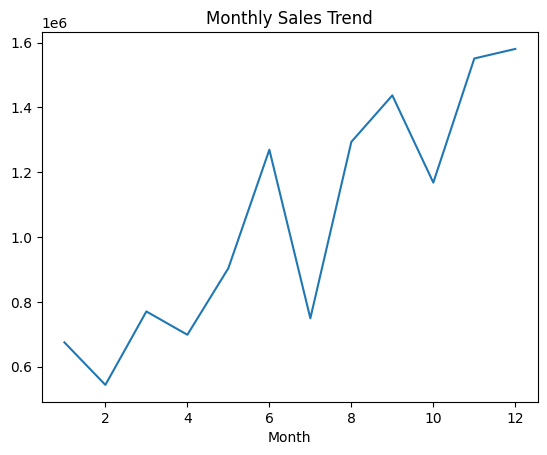

In [129]:
monthly_sales.plot(kind="line")

plt.title("Monthly Sales Trend")

plt.savefig(

    "reports/monthly_sales.png",

    bbox_inches="tight"

)

plt.show()

In [130]:
import time

start_time = time.time()

In [131]:
end_time = time.time()

print("Execution Time :")

print(round(end_time - start_time,2), "seconds")

Execution Time :
7.88 seconds


In [132]:
def load_data(path):

    return pd.read_excel(path)

In [133]:
def clean_data(data):

    data.drop_duplicates(inplace=True)

    return data

In [134]:
def create_month_column(data):

    data["Month"] = data["Order Date"].dt.month

    return data

In [135]:
def main():

    print("Loading Dataset...")

    print("Cleaning Data...")

    print("Generating KPI Reports...")

    print("Generating MIS Reports...")

    print("Exporting Reports...")

    print("Completed Successfully!")



main()

Loading Dataset...
Cleaning Data...
Generating KPI Reports...
Generating MIS Reports...
Exporting Reports...
Completed Successfully!


In [136]:
def main():

    data = load_data("data/Global_Superstore.xlsx")

    data = clean_data(data)

    ...

    ...

    print("MIS Report Generated")